In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [125]:
df_avg = pd.read_csv("../../../data/processed/3_year/Midfielders/Avg_Top5_Midfielders.csv")

In [126]:
df_avg.head()

,player id,player,team,team id,league,position,number_of_seasons,minutesplayed,possessionwonattthird,shotfromsetpiece,...,goals_per_xg,shots_on_target_pct,inside_box_shot_pct,assist_conversion,xa_per_keypass,final_third_pass_pct,dispossessed_per_touch,possession_lost_per_touch,defensive_actions_per90,weak_foot_goals_pct
0,791,James Milner,Brighton & Hove Albion,30,England Premier League,Midfielders,3,584.333333,2.666667,0.0,...,0.684932,0.266667,0.600000,0.107143,0.089643,0.308710,0.006536,0.159041,7.341700,0.000000
1,15466,Luka Modrić,AC Milan,2692,Italy Serie A,Midfielders,3,2112.000000,13.666667,1.0,...,1.357466,0.358209,0.328358,0.084270,0.089101,0.318022,0.006506,0.137513,8.181818,0.333333
2,17651,Santi Cazorla,Real Oviedo,2851,Spain La Liga,Midfielders,1,940.000000,6.000000,1.0,...,0.000000,0.142857,0.428571,0.037037,0.080741,0.340426,0.014455,0.232589,7.659574,0.000000
3,21949,Óscar Trejo,Rayo Vallecano,2818,Spain La Liga,Midfielders,3,683.666667,6.666667,0.0,...,0.609756,0.250000,0.666667,0.025641,0.075128,0.427263,0.050372,0.247281,7.503657,0.000000
4,35612,Axel Witsel,Girona FC,24264,Spain La Liga,Midfielders,3,2058.333333,4.000000,0.0,...,0.879765,0.285714,0.821429,0.136364,0.094545,0.119441,0.005409,0.090653,7.170850,0.000000


In [127]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['rating','minutesplayed','number_of_seasons'])

In [128]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [129]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

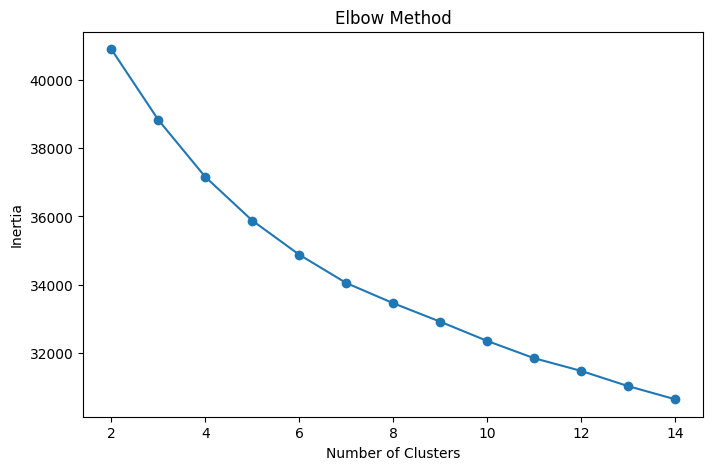

In [130]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [131]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

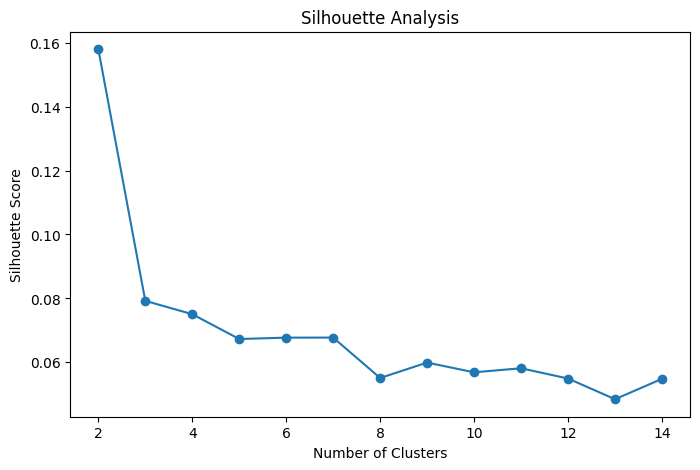

In [132]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [133]:
x=6
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [134]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_6,0,1,2,3,4,5
number_of_seasons,2.246753,2.639456,2.736842,2.343590,2.509677,2.550725
minutesplayed,1561.415584,1822.845805,1813.618421,1527.341026,1458.166667,1546.685990
possessionwonattthird,6.412338,10.893424,14.734649,6.502564,10.807527,7.628019
shotfromsetpiece,0.641775,1.058957,3.572368,0.176068,0.596774,0.265700
rating,6.792294,7.001658,7.160405,6.783041,6.829979,6.823599
accuratecrossespercentage,25.119434,25.883819,26.607349,22.962483,22.323668,20.451567
accuratelongballspercentage,42.581003,60.736168,59.755865,54.059609,54.101271,47.038593
accuratepassespercentage,79.742365,87.679965,82.984405,84.786478,80.135407,77.747354
successfuldribblespercentage,45.456884,54.998038,47.787594,54.805302,45.323503,45.717182
tackleswonpercentage,60.745243,59.240715,58.667182,58.393474,59.246302,55.901435


In [135]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','goals_per90','expectedgoals_per90'], 
    title=f"Forwards Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

In [136]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [137]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [138]:
pca_sizes = [14,16,18,20,22,24,26,28]

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [139]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(6, 14):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [140]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,14,6,0.103790
1,14,7,0.101009
8,16,6,0.097233
3,14,9,0.095930
2,14,8,0.095827
9,16,7,0.095074
16,18,6,0.093062
7,14,13,0.089372
11,16,9,0.089170
10,16,8,0.089001


In [141]:
x=18
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
possessionwonattthird,0.131940,0.128954,0.068665,-0.066521,0.067527,0.088879,-0.039660,-0.187590,-0.053230,0.031716,0.046453,-0.339521,0.221311,-0.041042,0.259218,0.136992,-0.036409,-0.013254
shotfromsetpiece,0.106625,0.164573,-0.007425,0.139318,0.186428,-0.176827,0.020683,0.141609,0.005896,0.052870,0.087286,-0.017601,-0.161867,-0.149186,0.050280,-0.013505,0.064019,0.042287
accuratecrossespercentage,0.002072,0.079869,-0.052768,0.086573,0.043200,0.037782,0.033937,0.010093,0.059654,0.154604,0.402617,0.358905,-0.017797,0.085374,-0.147872,0.293309,-0.281099,0.102572
accuratelongballspercentage,0.031053,0.211666,0.098819,-0.184391,-0.114912,-0.080119,-0.200572,-0.036422,-0.095536,0.199432,-0.019766,0.134270,-0.012431,0.024837,0.046875,-0.046006,0.021709,0.074430
accuratepassespercentage,-0.083210,0.269292,-0.024496,-0.187653,-0.212846,-0.031970,-0.123511,0.028138,-0.070011,0.100393,0.031777,0.054879,-0.092920,0.013332,0.001451,0.025097,-0.086141,0.046964
successfuldribblespercentage,-0.078136,0.142050,0.071342,-0.099488,-0.000875,-0.028603,-0.064433,-0.043482,0.238784,0.155361,-0.152340,0.130776,0.310909,0.014665,-0.115233,-0.107981,0.140737,-0.006776
tackleswonpercentage,0.011777,0.009328,-0.004827,0.015887,-0.017006,0.132089,0.056415,0.027660,0.026839,0.222891,0.498762,-0.058898,0.252866,0.314831,-0.048291,-0.235099,0.360363,0.236320
goalconversionpercentage,0.124261,0.023680,-0.294550,-0.230106,0.026406,0.112549,0.183345,-0.061386,-0.052329,-0.020692,0.061995,0.048851,-0.042046,-0.092009,-0.024131,-0.018026,0.057950,-0.005033
penaltyconversion,0.100855,0.090425,-0.028187,-0.003551,0.108000,-0.103141,-0.063915,-0.052807,0.045949,-0.076237,0.254804,-0.089936,-0.101576,-0.363248,0.272697,-0.147363,0.103034,0.255244
setpiececonversion,0.052638,0.066508,-0.028465,0.010684,0.136822,-0.087108,0.184420,0.204076,-0.116116,0.394699,-0.136128,-0.356969,-0.011245,0.111821,-0.016556,-0.176955,-0.233339,-0.001064


In [142]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
final_third_pass_pct        0.241873
expectedgoals_per90         0.226188
goals_per90                 0.225454
blockedshots_per90          0.202265
bigchancescreated_per90     0.199297
keypasses_per90             0.196985
possessionlost_per90        0.192828
shotsofftarget_per90        0.189975
assists_per90               0.187460
successfuldribbles_per90    0.178570
Name: PC1, dtype: float64

PC2
accuratepasses_per90              0.323687
accuratefinalthirdpasses_per90    0.294894
accuratelongballs_per90           0.274625
accuratepassespercentage          0.269292
aeriallost_per90                  0.242073
possession_lost_per_touch         0.235072
groundduelswonpercentage          0.223906
accuratelongballspercentage       0.211666
duellost_per90                    0.196865
inside_box_shot_pct               0.192925
Name: PC2, dtype: float64

PC3
groundduelswon_per90        0.366129
goalconversionpercentage    0.294550
duellost_per90              0.272628
goals_per_xg          

In [143]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [144]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [145]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [146]:
cluster=6

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_6','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_summary.transpose())

pca_cluster_6,0,1,2,3,4,5
number_of_seasons,2.210191,2.638889,2.382653,2.512500,2.569444,2.731343
minutesplayed,1545.227176,1817.347222,1549.880102,1460.522917,1547.263889,1845.644279
possessionwonattthird,6.253715,10.846065,6.749150,11.012500,7.745370,14.805970
shotfromsetpiece,0.582803,1.122685,0.181973,0.619792,0.300926,3.902985
rating,6.783551,7.009053,6.790130,6.842241,6.821549,7.171930
accuratecrossespercentage,25.117401,26.306310,22.726067,22.314114,20.610944,26.931158
accuratelongballspercentage,42.426755,60.358311,54.862245,54.556232,47.199293,59.211596
accuratepassespercentage,79.458395,87.592236,85.257800,80.350935,77.786261,82.678707
successfuldribblespercentage,45.740804,54.717214,54.888832,45.534127,45.830529,47.455776
tackleswonpercentage,60.500625,59.313459,58.496011,58.976887,56.169402,59.156844


In [147]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_{cluster}",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Midfielders Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [148]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_6"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                 player                    team
44       Phillipp Mwene         1. FSV Mainz 05
127        Javier Muñoz                  Getafe
739          Chris Rigg              Sunderland
124      Hassane Kamara                 Udinese
522      Rassoul Ndiaye                Le Havre
542     Sergio Carreira              Celta Vigo
347        Derrick Köhn      1. FC Union Berlin
311      Sean Longstaff            Leeds United
564          Hugo Bueno           Wolverhampton
751        Bence Dárdai           VfL Wolfsburg
364    Domagoj Bradarić           Hellas Verona
662        Théo Le Bris                 Lorient
292            Tim Weah  Olympique de Marseille
488       Jon Moncayola                 Osasuna
220       Vitaly Janelt               Brentford
54       Thomas Delaine                Le Havre
585       Josué Casimir                 Auxerre
143  Pasquale Mazzocchi              SSC Napoli
303     Robin Fellhauer             FC Augsburg
164   Kingsley Ehizibu

In [149]:
cluster_map = {
    0: "Wide Progressor",
    1: "Controller",
    2: "Destroyer",
    3: "Wide Creator",
    4: "Box-to-Box",
    5: "Elite Creator"
}

df_avg["cluster_name"] = df_avg["pca_cluster_6"].map(cluster_map)

In [150]:
df_avg.to_csv("../../../data/processed/3_year/Midfielders/Avg_Top5_Midfielders_Clustered.csv",index=False)